Objective:
The objective of this assignment is to apply Decision Tree Classification to a given dataset, analyse the performance of the model, and interpret the results.


Tasks:

In [1]:
# 1. Data Preparation::

In [154]:
## importing packeges
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [155]:
# Load the dataset into your preferred data analysis environment (e.g., Python with libraries like Pandas and NumPy).
df=pd.read_excel('heart_disease_new.xlsx')

2. Exploratory Data Analysis (EDA):

In [156]:
# Perform exploratory data analysis to understand the structure of the dataset.
# Check for missing values, outliers, and inconsistencies in the data.
# Visualize the distribution of features, including histograms, box plots, and correlation matrices.

In [157]:
df.shape

(908, 13)

In [158]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,Male,typical angina,145,233,True,lv hypertrophy,150,False,2.3,downsloping,fixed defect,0
1,41,Male,atypical angina,135,203,False,normal,132,False,0.0,flat,fixed defect,0
2,57,Male,asymptomatic,140,192,False,normal,148,False,0.4,flat,fixed defect,0
3,52,Male,typical angina,118,186,False,lv hypertrophy,190,False,0.0,flat,fixed defect,0
4,57,Male,asymptomatic,110,201,False,normal,126,True,1.5,flat,fixed defect,0


In [159]:
for col in df.select_dtypes(include='bool').columns:
    df[col] = df[col].astype(int)

In [160]:
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch',
       'exang', 'oldpeak', 'slope', 'thal', 'num'],
      dtype='object')

In [161]:
## seperating numerical  and categorial data

In [162]:
df_numerical = df.select_dtypes(include = ['int64','float64'])
df_numerical.head()

,age,trestbps,chol,fbs,thalch,oldpeak,num
0,63,145,233,1,150,2.3,0
1,41,135,203,0,132,0.0,0
2,57,140,192,0,148,0.4,0
3,52,118,186,0,190,0.0,0
4,57,110,201,0,126,1.5,0


In [163]:

df_categorial = df.select_dtypes(include = ['object','character'])
df_categorial.head()

,sex,cp,restecg,exang,slope,thal
0,Male,typical angina,lv hypertrophy,False,downsloping,fixed defect
1,Male,atypical angina,normal,False,flat,fixed defect
2,Male,asymptomatic,normal,False,flat,fixed defect
3,Male,typical angina,lv hypertrophy,False,flat,fixed defect
4,Male,asymptomatic,normal,True,flat,fixed defect


2. Exploratory Data Analysis (EDA):

In [164]:
# Perform exploratory data analysis to understand the structure of the dataset.
# Check for missing values, outliers, and inconsistencies in the data.

In [165]:
### checking for missing values
df.isnull().sum()

age          0
sex          0
cp           0
trestbps     0
chol         0
fbs          0
restecg      0
thalch       0
exang        0
oldpeak     62
slope        0
thal         0
num          0
dtype: int64

In [166]:
### we have null values with 'oldpeak'
### filling null values with mean value
df.fillna(df.mean(numeric_only=True), inplace=True)
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
thal        0
num         0
dtype: int64

In [167]:
## now there is no missing data

In [168]:
### checking for duplocated data
df.duplicated().sum()

np.int64(0)

In [169]:
### there is no duplicated data

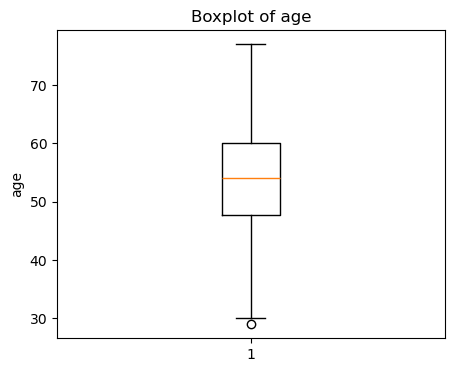

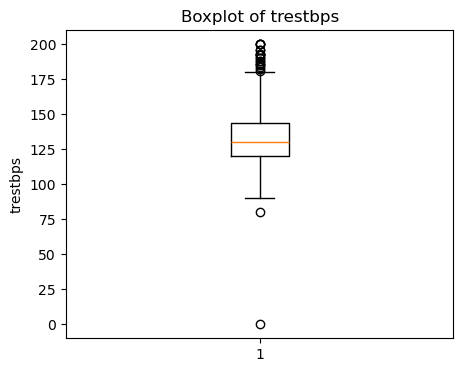

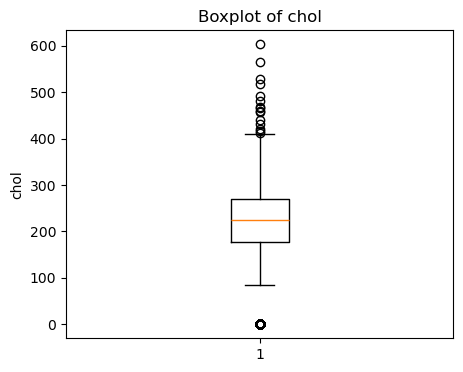

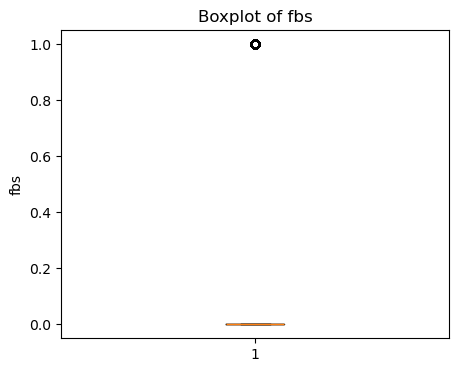

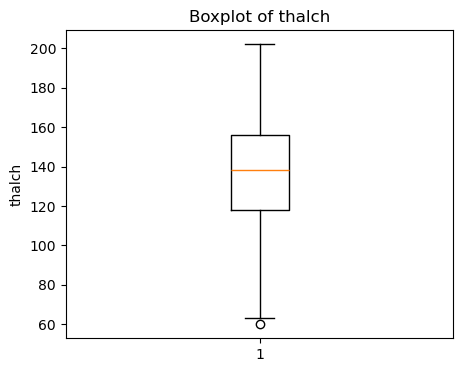

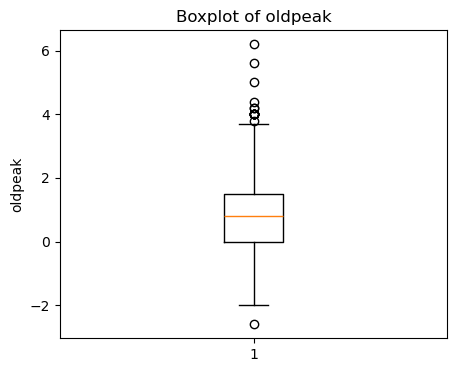

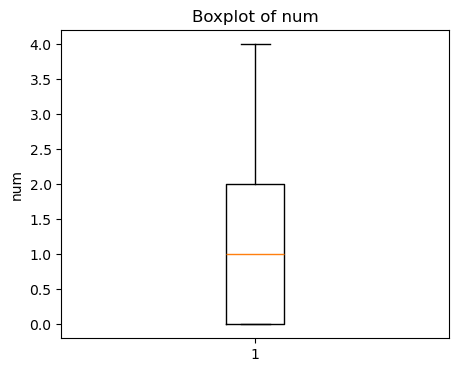

In [170]:
### checking for outliers
for col in df_numerical:
    plt.figure(figsize=(5,4))
    plt.boxplot(df[col])
    plt.title(f'Boxplot of {col}')
    plt.ylabel(col)
    plt.show()

In [171]:
## outlier capping
def outlier_capping(df,columns):
    Q1= df[columns].quantile(0.25)
    Q3= df[columns].quantile(0.75)
    IQR= Q3-Q1
    lower_extreme= Q1-1.5*IQR
    upper_extreme= Q3+1.5*IQR
    df_numerical[columns]= df[columns].apply(lambda x: lower_extreme if x<lower_extreme else upper_extreme if x>upper_extreme else x)
for col in df_numerical:
    outlier_capping(df_numerical,col)


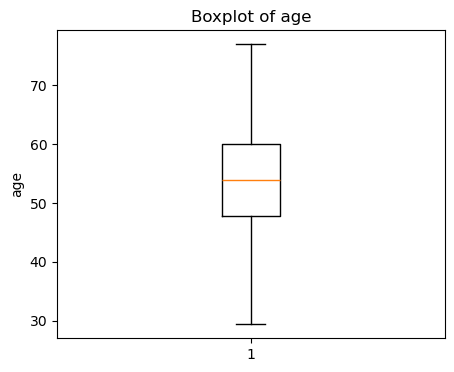

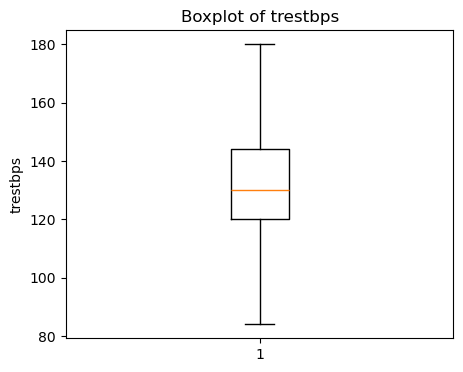

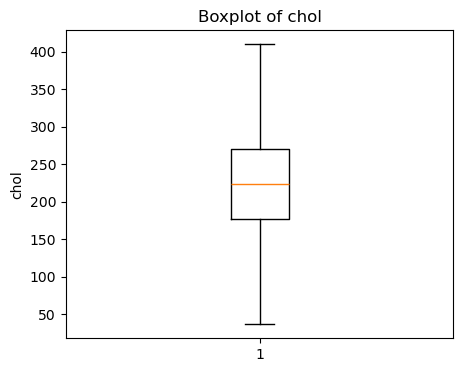

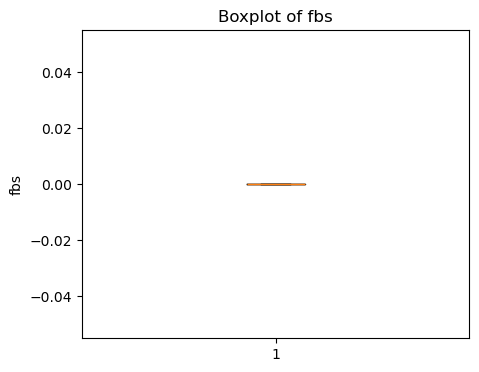

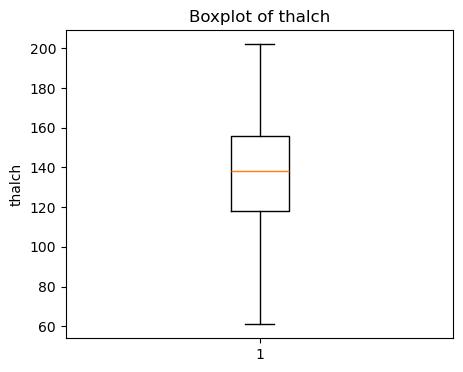

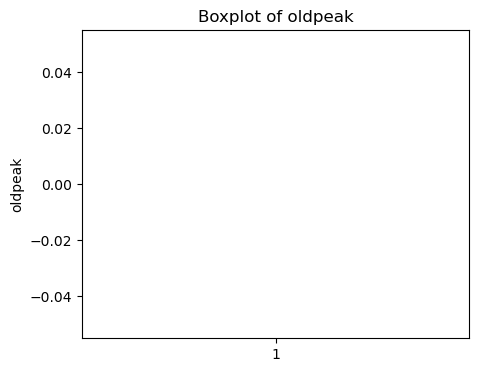

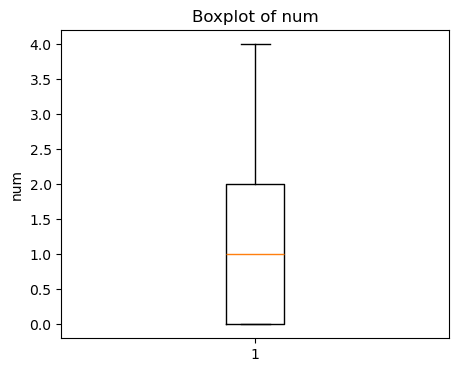

In [172]:
### boxplot after capping
for col in df_numerical:
    plt.figure(figsize=(5,4))
    plt.boxplot(df_numerical[col])
    plt.title(f'Boxplot of {col}')
    plt.ylabel(col)
    plt.show()

In [173]:
### now the outliers are set to lower extreme and upper extreme values.

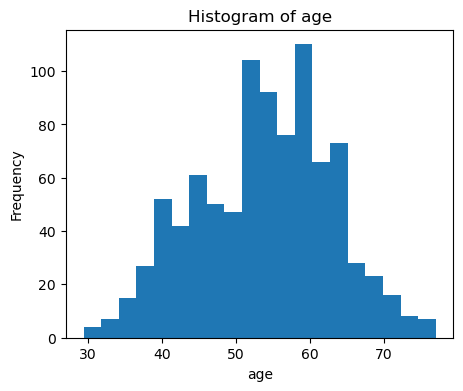

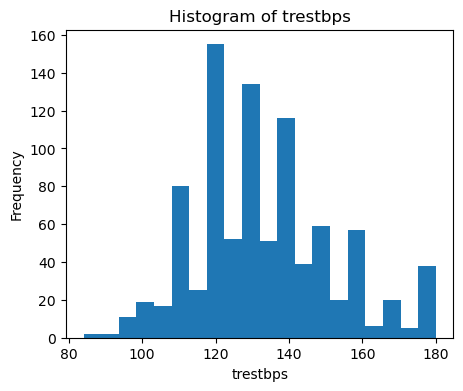

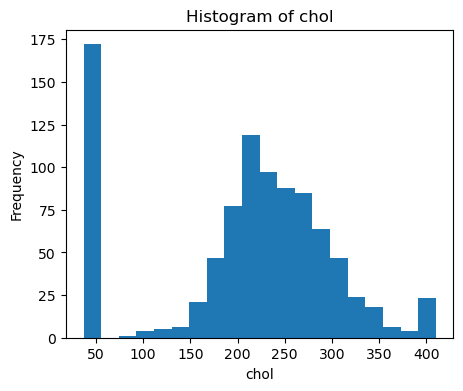

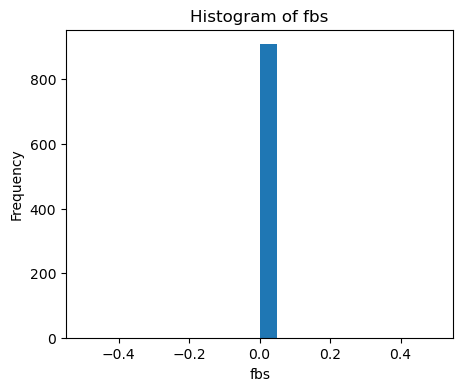

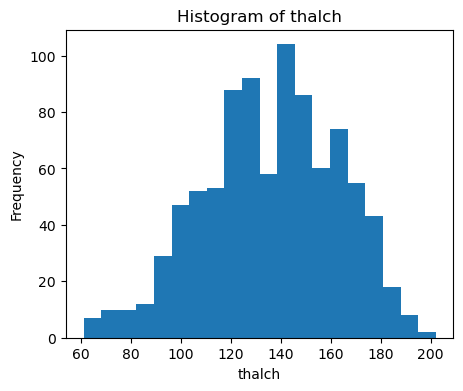

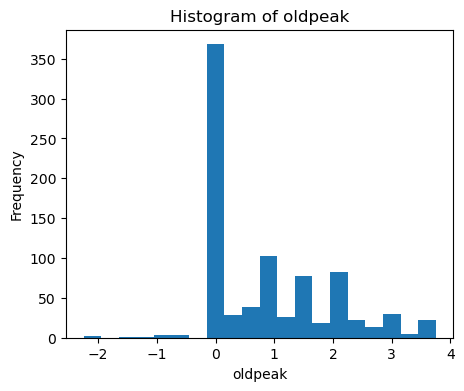

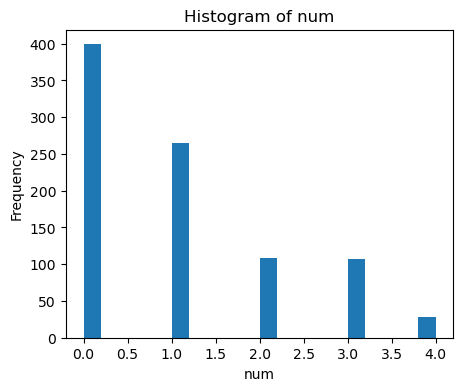

In [174]:
## histogram for numerical columns
for col in df_numerical:
    plt.figure(figsize=(5,4))
    plt.hist(df_numerical[col].dropna(), bins=20)
    plt.title(f"Histogram of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()


In [175]:
## finding skewness to check for the data distribution
for col in df_numerical:
    skew_col = df_numerical[col].skew()
    print(f"skewness for {col}" , skew_col)

skewness for age -0.13600179818663635
skewness for trestbps 0.4938140428870926
skewness for chol -0.5432363980879141
skewness for fbs 0.0
skewness for thalch -0.21877425129971895
skewness for oldpeak 0.8185186538653212
skewness for num 0.9514085875909324


In [176]:
### based on the skewness for all columns, data is having slightly to moderate positive and negative skew and it is not normally distributes.

In [177]:
## correlation matrix:
#corr = df[df_numerical].apply(pd.to_numeric, errors='coerce').corr()
#corr = df_numerical.corr()
corr = df_numerical.corr()

In [178]:
corr


,age,trestbps,chol,fbs,thalch,oldpeak,num
age,1.000000,0.262066,-0.092411,NaN,-0.328068,0.245770,0.326493
trestbps,0.262066,1.000000,0.126479,NaN,-0.131777,0.172790,0.142645
chol,-0.092411,0.126479,1.000000,NaN,0.194575,0.031927,-0.228308
fbs,NaN,NaN,NaN,NaN,NaN,NaN,NaN
thalch,-0.328068,-0.131777,0.194575,NaN,1.000000,-0.142658,-0.323060
oldpeak,0.245770,0.172790,0.031927,NaN,-0.142658,1.000000,0.437646
num,0.326493,0.142645,-0.228308,NaN,-0.323060,0.437646,1.000000


3. Feature Engineering:

If necessary, perform feature engineering techniques such as encoding categorical variables, scaling numerical features, or handling missing values.

In [182]:
# Handle Missing Values
# Fill categorical columns with mode
df_categorial = df.select_dtypes(include=["object", "bool"])
# for col in df_categorial:
#    df_categorial[col] = df_categorial[col].fillna(df_categorial[col].mode()[0])

df_categorial.head()


,sex,cp,restecg,exang,slope,thal
0,Male,typical angina,lv hypertrophy,False,downsloping,fixed defect
1,Male,atypical angina,normal,False,flat,fixed defect
2,Male,asymptomatic,normal,False,flat,fixed defect
3,Male,typical angina,lv hypertrophy,False,flat,fixed defect
4,Male,asymptomatic,normal,True,flat,fixed defect


In [183]:
df_categorial.isnull().sum()

sex        0
cp         0
restecg    0
exang      0
slope      0
thal       0
dtype: int64

In [186]:
df_categorial.duplicated().sum()

np.int64(649)

In [187]:
df_categorial.drop_duplicates(inplace=True,ignore_index=True)

In [188]:
df_categorial.duplicated().sum()

np.int64(0)

4. Decision Tree Classification:

In [189]:
# Split the dataset into training and testing sets (e.g., using an 80-20 split).
from sklearn.model_selection import train_test_split

In [196]:
# Features and Target
# column 'num' is the Target column.(target [0=no heart disease; 1,2,3,4 = stages of heart disease ])
features = df_numerical.drop("num", axis=1)   # replace "target" with your label column name
target = df_numerical["num"]


In [197]:
features.columns

Index(['age', 'trestbps', 'chol', 'fbs', 'thalch', 'oldpeak'], dtype='object')

In [201]:
features.shape

(908, 6)

In [199]:
target.head()

0    0
1    0
2    0
3    0
4    0
Name: num, dtype: int64

In [202]:
target.shape

(908,)

In [204]:
x_train, x_test, y_train, y_test = train_test_split(features,target,test_size=0.2,random_state=42,stratify=target)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

    

(726, 6)
(182, 6)
(726,)
(182,)


In [234]:
## fit and transform (scaling)
from sklearn.preprocessing import StandardScaler, label_binarize
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)


In [235]:
#Implement a Decision Tree Classification model using a library like scikit-learn.
# Decision tree classification(scikit learn)
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score,roc_curve
                             

In [236]:
#Train the model on the training set and evaluate its performance on the testing set
# using appropriate evaluation metrics (e.g., accuracy, precision, recall, F1-score, ROC-AUC).

In [237]:
# Train Decision Tree Model
dt_model = DecisionTreeClassifier(criterion="gini", max_depth=5, random_state=42)  ## dt_model is decision tree model

dt_model.fit(x_train, y_train)  ## fitting x_train and y_train


DecisionTreeClassifier(max_depth=5, random_state=42)

In [238]:
#  Decision tree Predictions
y_pred = dt_model.predict(x_test)

In [239]:
# Get predicted probabilities for each class
y_pred_proba = dt_model.predict_proba(x_test)  # this is sigmoid value

In [240]:
y_test_bin = label_binarize(y_test, classes=dt_model.classes_)  # shape: (n_samples, n_classes), this value will be used to find Roc_score

In [242]:
# Evaluation of the model dt_model
Accuracyscore = accuracy_score(y_test, y_pred)
Precisionscore = precision_score(y_test, y_pred, average='weighted') ## as our target('num') is having two classes(multiclass) '0' and '0', so, we
  # are taking average = weighted' to take the average from multi classes
recallscore   = recall_score(y_test, y_pred, average = 'weighted')
f1score  = f1_score(y_test, y_pred,average='weighted')
rocaucscore  = roc_auc_score(y_test_bin, y_pred_proba,multi_class='ovr', average='weighted')
Classificationreport = classification_report(y_test, y_pred)
Confusionmatrix = confusion_matrix(y_test, y_pred)


In [243]:
print("Accuracy_score:", Accuracyscore)
print("Precision Score:",Precisionscore)
print("Recall Score:",recallscore)
print("F1 Score:", f1score)
print("Roc Auc Score:", rocaucscore)
print("\nClassification Report:\n", Classificationreport)
print("\nConfusion Matrix:\n", Confusionmatrix)

Accuracy_score: 0.510989010989011
Precision Score: 0.5055806296877725
Recall Score: 0.510989010989011
F1 Score: 0.4998555938405562
Roc Auc Score: 0.7249412225514769

Classification Report:
               precision    recall  f1-score   support

           0       0.74      0.66      0.70        80
           1       0.39      0.58      0.47        53
           2       0.21      0.14      0.17        22
           3       0.38      0.29      0.32        21
           4       0.00      0.00      0.00         6

    accuracy                           0.51       182
   macro avg       0.34      0.33      0.33       182
weighted avg       0.51      0.51      0.50       182


Confusion Matrix:
 [[53 21  3  3  0]
 [14 31  3  5  0]
 [ 4 14  3  1  0]
 [ 0 12  3  6  0]
 [ 1  2  2  1  0]]


5. Hyperparameter Tuning:

Perform hyperparameter tuning to optimize the Decision Tree model. Experiment with different hyperparameters such as maximum depth, minimum samples split, and criterion.

In [244]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, f1_score

In [245]:
# definig hyper parameter grid
param_grid = {
    'max_depth': [None, 5, 10, 15, 20],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10],
    'criterion': ['gini', 'entropy']
}

In [246]:
# initialize gridsearchCV
grid_search = GridSearchCV(
    estimator=dt_model,
    param_grid=param_grid,
    scoring='f1_weighted',  # weighted F1-score for multiclass
    cv=5,                   # 5-fold cross-validation
    n_jobs=-1,              # use all cores
    verbose=1
)

In [247]:
# fit grid search
grid_search.fit(x_train, y_train)

Fitting 5 folds for each of 160 candidates, totalling 800 fits


GridSearchCV(cv=5,
             estimator=DecisionTreeClassifier(max_depth=5, random_state=42),
             n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [None, 5, 10, 15, 20],
                         'min_samples_leaf': [1, 2, 5, 10],
                         'min_samples_split': [2, 5, 10, 20]},
             scoring='f1_weighted', verbose=1)

In [248]:
### find best hyperparameters
print("Best Hyperparameters:", grid_search.best_params_)
best_dt = grid_search.best_estimator_

Best Hyperparameters: {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2}


In [250]:
### evaluate on test set
y_pred = best_dt.predict(x_test)

print("Classification Report:")
print(classification_report(y_test, y_pred, digits=4))

Classification Report:
              precision    recall  f1-score   support

           0     0.7361    0.6625    0.6974        80
           1     0.3875    0.5849    0.4662        53
           2     0.2143    0.1364    0.1667        22
           3     0.3750    0.2857    0.3243        21
           4     0.0000    0.0000    0.0000         6

    accuracy                         0.5110       182
   macro avg     0.3426    0.3339    0.3309       182
weighted avg     0.5056    0.5110    0.4999       182



6. Model Evaluation and Analysis:

In [251]:
# Analyse the performance of the Decision Tree model using the evaluation metrics obtained.

# Accuracy =0.51  ,52% of all samples are classified correctly.
# precision= 0.506, 50.6% → The model is correct about half of the time when predicting a class.
# Recall = 0.511, 51.1% → The model captures about half of the true instances per class.
# F1score = 0.50, 0.50 → Confirms the model has poor balance between correctly predicting classes and covering actual instances.
# ROC AUC Score = 0.725, 0.724 → Much better than the other metrics!
# Suggests that the model can rank class probabilities reasonably well, even if the predicted class labels aren’t accurate.

In [ ]:
#Visualize the decision tree structure to understand the rules learned by the model and identify important features

In [252]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

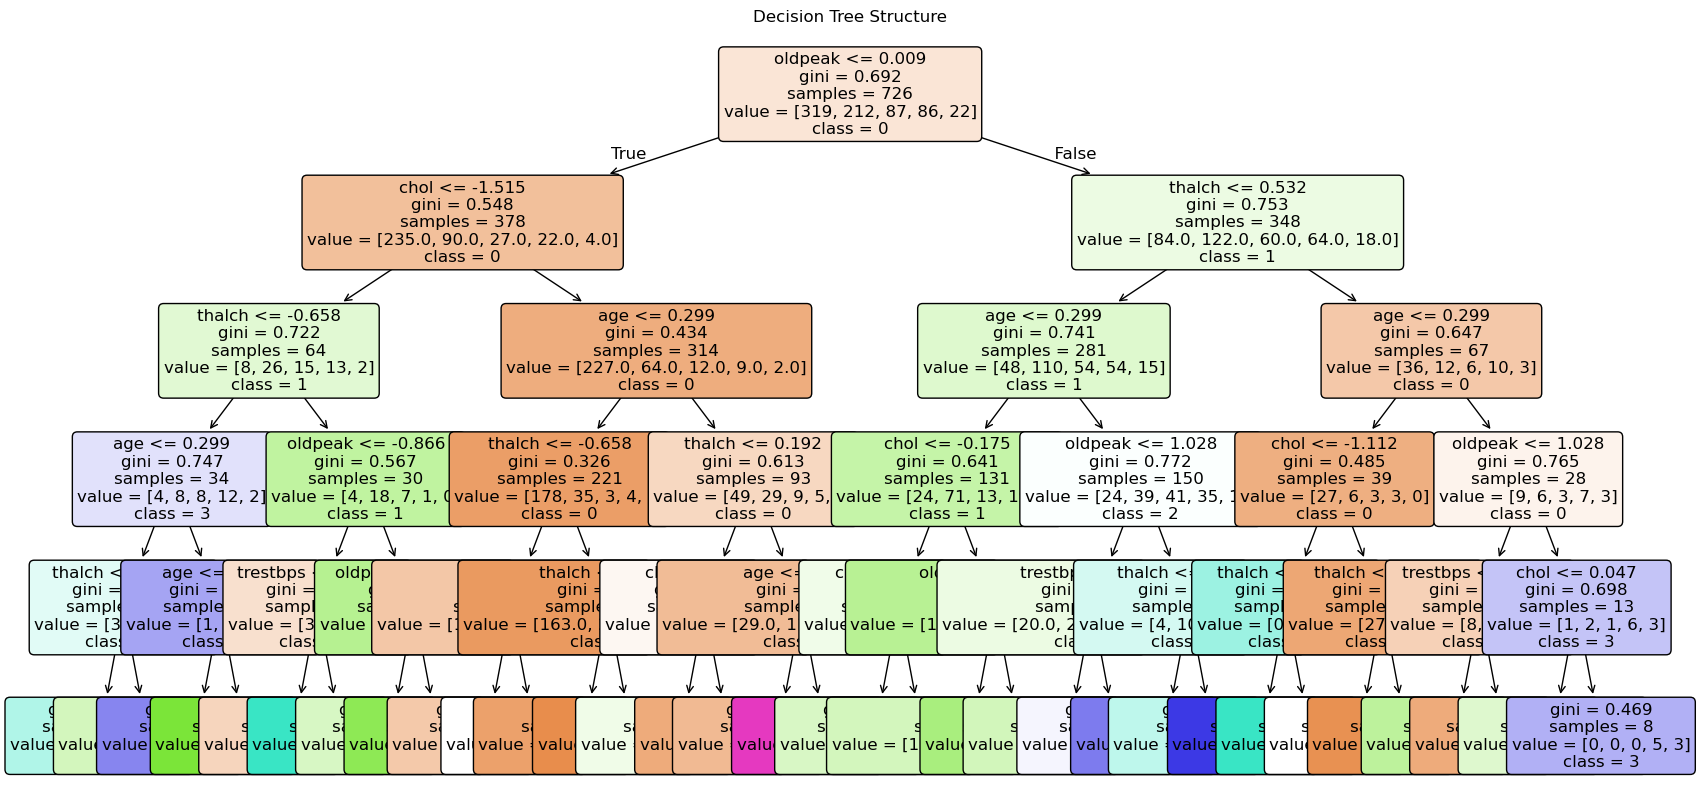

In [253]:
# Visualize the trained Decision Tree
plt.figure(figsize=(20, 10))  # Adjust size for clarity
plot_tree(
    best_dt,                    # your trained Decision Tree
    feature_names=features.columns,    # feature names
    class_names=[str(c) for c in best_dt.classes_],  # class names
    filled=True,                # color nodes by class
    rounded=True,               # round the corners
    fontsize=12                 # adjust font size
)
plt.title("Decision Tree Structure")
plt.show()